# Grover's Algorithm — 10-Qubit Implementation
### Quantum Computing Course Project



## Objective

The goal of this project is to implement Grover’s search algorithm using Qiskit in order to identify specific marked states within a large search space. 

The implementation must be constructed entirely using quantum gates, including the oracle, diffusion operator, and Grover iterations. Finally, the circuit should be executed and visualized using a measurement histogram, where the marked states appear with the highest probability.

---
## Setup & Imports

In [1]:
# ── Standard library ──
import math

# ── Qiskit ──
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import MCMTGate, ZGate   # used in IBM-style oracle only
from qiskit.visualization import plot_histogram

# ── Qiskit Aer (local simulator) ──
from qiskit_aer import Aer

# ── Utilities ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✓")


All imports successful ✓


---
## Problem Setup

We consider a quantum system consisting of 10 qubits, representing a search space of size:

2^10 = 1024 possible states.

We define a function f(x) such that:
- f(x) = 1 for selected target states
- f(x) = 0 for all other states

The marked states used in this implementation are:

0110011010  
1101010001

The objective is to design a Grover circuit that increases the probability of measuring these states.


In [3]:
import math

# ── Configuration ──
qubit_count   = 10
target_list   = ["0110011010", "1101010001"]
num_shots     = 8192

# ── Computed values ──
total_states  = 2 ** qubit_count
num_targets   = len(target_list)

angle_theta   = math.asin(math.sqrt(num_targets / total_states))
optimal_iter  = math.floor(math.pi / (4 * angle_theta))

# ── Iteration values to test ──
iteration_set = [1, 3, 5, 10, optimal_iter]

# ── Display information ──
print(f"Total Qubits        : {qubit_count}")
print(f"Search Space Size   : 2^{qubit_count} = {total_states}")

print(f"\nTarget States ({num_targets} total):")
for state in target_list:
    print(f"  {state}  → decimal value: {int(state, 2)}")

print(f"\nθ (theta) = arcsin(√(M/N)) = {angle_theta:.6f} radians")
print(f"Optimal iterations ≈ ⌊π / (4θ)⌋ = {optimal_iter}")

print(f"\nIterations to evaluate: {iteration_set}")

# ── Theoretical Probability Table ──
print("\nIteration vs Theoretical Probability")
print("-" * 40)
print(f"{'Iter':>6}  {'P(marked)':>12}")
print("-" * 40)

for itr in iteration_set:
    probability = math.sin((2 * itr + 1) * angle_theta) ** 2
    
    tag = " <-- optimal" if itr == optimal_iter else ""
    
    print(f"{itr:>6}  {probability:>12.4f}{tag}")

Total Qubits        : 10
Search Space Size   : 2^10 = 1024

Target States (2 total):
  0110011010  → decimal value: 410
  1101010001  → decimal value: 849

θ (theta) = arcsin(√(M/N)) = 0.044209 radians
Optimal iterations ≈ ⌊π / (4θ)⌋ = 17

Iterations to evaluate: [1, 3, 5, 10, 17]

Iteration vs Theoretical Probability
----------------------------------------
  Iter     P(marked)
----------------------------------------
     1        0.0175
     3        0.0927
     5        0.2184
    10        0.6410
    17        0.9994 <-- optimal


---
# Section 1 — Oracle Construction

The oracle is the core of Grover's algorithm. It encodes the search problem by applying a
phase of $-1$ to each marked state, leaving all other states unchanged.

We provide **two oracle implementations**:
- **Part A:** IBM documentation-style oracle using `MCMTGate(ZGate(), ...)` (direct port from IBM tutorial)
- **Part B:** Custom phase-kickback oracle built from scratch using `mcx` and an ancilla qubit

Both oracles are **fully manual** — no `qiskit.algorithms.Grover` or `grover_operator()` is used anywhere.


---
## Part A — IBM-Style Oracle (MCMTGate)

Adapted directly from the IBM Quantum documentation oracle subroutine.
Uses `MCMTGate(ZGate(), num_controls, 1)` to implement the multi-controlled-Z gate,
combined with X-gates on the `'0'` positions of the target string (open-control trick).

**Reference:** https://quantum.cloud.ibm.com/docs/en/tutorials/grovers-algorithm


In [4]:
def grover_oracle(marked_states):
    """
    Grover oracle — IBM documentation subroutine.

    Applies a −1 phase to each state listed in marked_states by using:
      1. X gates on qubits where the target bit-string has '0'  (open-control trick)
      2. MCMTGate(ZGate(), n−1, 1)  — multi-controlled-Z on all n qubits
      3. X gates again to restore qubit values

    Parameters
    ----------
    marked_states : str or list of str
        Binary string(s) to phase-flip.  All must have the same length.

    Returns
    -------
    QuantumCircuit
        n-qubit oracle circuit.
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits, name='Oracle A\n(IBM-style)')

    for target in marked_states:
        # Qiskit uses little-endian qubit ordering → reverse the bit-string
        rev_target = target[::-1]

        # Qubits where the target has '0' need an X gate (open-control trick)
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == '0']

        if zero_inds:
            qc.x(zero_inds)              # flip '0' qubits to |1⟩

        # Multi-Controlled-Z: phase flip only when ALL qubits are |1⟩
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)

        if zero_inds:
            qc.x(zero_inds)              # restore the flipped qubits

    return qc


Oracle A (IBM-style)
  Qubits     : 10
  Depth      : 6
  Gate count : OrderedDict({'x': 20, 'mcmt': 2})
  Marks      : ['0110011010', '1101010001']


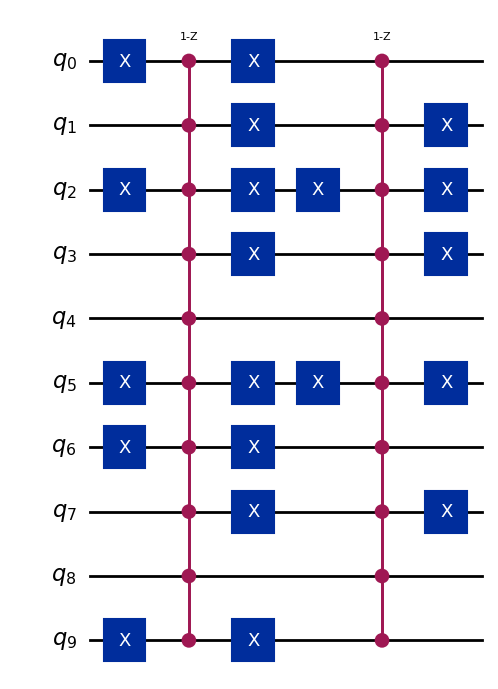

In [5]:
# ── Build and inspect the Part A oracle ──
oracle_A = grover_oracle(marked_states)

print(f"Oracle A (IBM-style)")
print(f"  Qubits     : {oracle_A.num_qubits}")
print(f"  Depth      : {oracle_A.depth()}")
print(f"  Gate count : {oracle_A.count_ops()}")
print(f"  Marks      : {marked_states}")

oracle_A.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 2 — Diffusion Operator (Manual Construction)

The diffuser implements the **inversion-about-the-mean** operation and is **identical** for
both Part A and Part B — it only acts on the $n$ data qubits.

$$
U_s = H^{\otimes n} \cdot U_0 \cdot H^{\otimes n}
$$

$U_0$ flips the phase of every state **except** $|0\cdots0\rangle$.  
Implemented as: $X^{\otimes n} \to \text{MCZ} \to X^{\otimes n}$, where
$\text{MCZ} = H_{n-1} \cdot \text{MCX}(0{..}n{-}2 \to n{-}1) \cdot H_{n-1}$.

> **Note:** This diffuser is built entirely from elementary gates — **no `grover_operator()` is used**.


In [6]:
def grover_diffuser(num_qubits):
    """
    Grover diffusion operator — inversion about the mean.

    Implements U_s = H^n · U_0 · H^n  where U_0 = (2|0><0| − I).

    Full gate sequence:
        H^⊗n  →  X^⊗n  →  H_{n-1}  →  MCX(0..n-2 → n-1)  →  H_{n-1}  →  X^⊗n  →  H^⊗n

    The inner  H · MCX · H  block implements a Multi-Controlled-Z (MCZ) gate
    using only the primitive MCX (multi-controlled-X / generalised Toffoli).

    Parameters
    ----------
    num_qubits : int
        Number of data qubits (same as the oracle).

    Returns
    -------
    QuantumCircuit
        num_qubits-qubit diffuser circuit.
    """
    qc = QuantumCircuit(num_qubits, name='Diffuser')

    # ── 1. H^⊗n : rotate to Hadamard basis ──
    qc.h(range(num_qubits))
    qc.barrier(label='H⊗n')

    # ── 2. X^⊗n : flip all qubits so |0…0⟩ → |1…1⟩ ──
    qc.x(range(num_qubits))
    qc.barrier(label='X⊗n')

    # ── 3. MCZ = H · MCX · H on last qubit ──
    #    Putting H on qubit n-1 before and after an MCX converts the
    #    bit-flip target into a phase-flip target, effectively making MCZ.
    qc.h(num_qubits - 1)
    qc.mcx(list(range(num_qubits - 1)), num_qubits - 1)
    qc.h(num_qubits - 1)
    qc.barrier(label='MCZ')

    # ── 4. X^⊗n : restore all qubits ──
    qc.x(range(num_qubits))
    qc.barrier(label='X⊗n')

    # ── 5. H^⊗n : rotate back to computational basis ──
    qc.h(range(num_qubits))

    return qc


Grover Diffuser (manual)
  Qubits     : 10
  Depth      : 7
  Gate count : OrderedDict({'h': 22, 'x': 20, 'barrier': 4, 'mcx': 1})


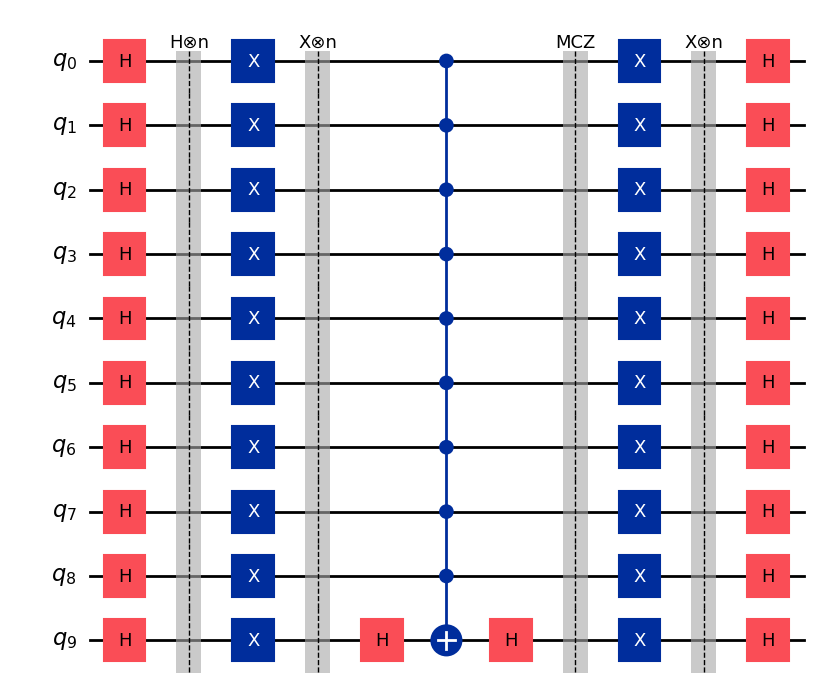

In [7]:
# ── Build and inspect the diffuser ──
diffuser = grover_diffuser(NUM_QUBITS)

print(f"Grover Diffuser (manual)")
print(f"  Qubits     : {diffuser.num_qubits}")
print(f"  Depth      : {diffuser.depth()}")
print(f"  Gate count : {diffuser.count_ops()}")

diffuser.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 3 — Custom Phase Kickback Oracle (Part B)

This is an **entirely different oracle implementation** built from scratch.
Instead of a direct multi-controlled-Z, it uses the **Phase Kickback** principle:

**Key idea:** Initialise an ancilla qubit in $|{-}\rangle = \frac{|0\rangle-|1\rangle}{\sqrt{2}}$
and use it as the **target** of a multi-controlled-X (MCX) gate.

$$
\text{MCX}\,|x\rangle|{-}\rangle =
\begin{cases}
-|x\rangle|{-}\rangle & \text{if } x = \omega \\
+|x\rangle|{-}\rangle & \text{otherwise}
\end{cases}
$$

The $-1$ phase **kicks back** into the control (data) register. The ancilla is uncomputed back to $|0\rangle$.

**Why this works:**
$$
X|{-}\rangle = X\frac{|0\rangle-|1\rangle}{\sqrt{2}} = \frac{|1\rangle-|0\rangle}{\sqrt{2}} = -|{-}\rangle
$$
An MCX gate, when its target is $|{-}\rangle$, produces a $-1$ global phase on the control subspace where all controls are $|1\rangle$.


In [8]:
def grover_oracle_kickback(marked_states):
    """
    Custom Grover oracle using Phase Kickback.

    Uses (n + 1) qubits:
      - Qubits 0 … n−1  :  data register (n = NUM_QUBITS)
      - Qubit n          :  ancilla qubit (initialised and returned to |0⟩)

    Per marked state:
      ┌──────────────────────────────────────────────────────────────────┐
      │  Prepare ancilla:  |0⟩ ──X──H──▶ |−⟩                             │
      │  For each marked state ω:                                        │
      │    1. X on qubits where ω has '0'   (open-control trick)         │
      │    2. MCX(data qubits → ancilla)    (kicks back −1 phase)        │
      │    3. X on same qubits              (undo open controls)         │
      │  Uncompute ancilla:  |−⟩ ──H──X──▶ |0⟩                           │
      └──────────────────────────────────────────────────────────────────┘

    Parameters
    ----------
    marked_states : str or list of str
        Binary string(s) to phase-flip.

    Returns
    -------
    QuantumCircuit
        (n+1)-qubit circuit; ancilla starts and ends in |0⟩.
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    ancilla    = num_qubits          # ancilla qubit index

    qc = QuantumCircuit(num_qubits + 1, name='Oracle B\n(Kickback)')

    # ── 1. Prepare ancilla in |−⟩ ──
    qc.x(ancilla)          # |0⟩ → |1⟩
    qc.h(ancilla)          # |1⟩ → |−⟩ = (|0⟩ − |1⟩)/√2
    qc.barrier(label='anc |−⟩')

    # ── 2. Phase-flip each marked state via kickback ──
    for target in marked_states:
        rev_target = target[::-1]          # little-endian ordering

        # Indices where target bit is '0' → need temporary X flip
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == '0']

        if zero_inds:
            qc.x(zero_inds)                # open-control: flip '0' bits

        # MCX: all data qubits → ancilla
        # When data == |ω⟩, MCX flips |−⟩ → −|−⟩  →  −1 kicks back to data
        qc.mcx(list(range(num_qubits)), ancilla)

        if zero_inds:
            qc.x(zero_inds)                # undo temporary flips

        qc.barrier(label=f'|{target}⟩')

    # ── 3. Uncompute ancilla back to |0⟩ ──
    qc.h(ancilla)          # |−⟩ → |1⟩
    qc.x(ancilla)          # |1⟩ → |0⟩

    return qc


Oracle B (Phase Kickback)
  Qubits (data + ancilla) : 11
  Depth                   : 10
  Gate count              : OrderedDict({'x': 22, 'barrier': 3, 'h': 2, 'mcx': 2})
  Ancilla qubit index     : 10  (unmeasured; returns to |0⟩)


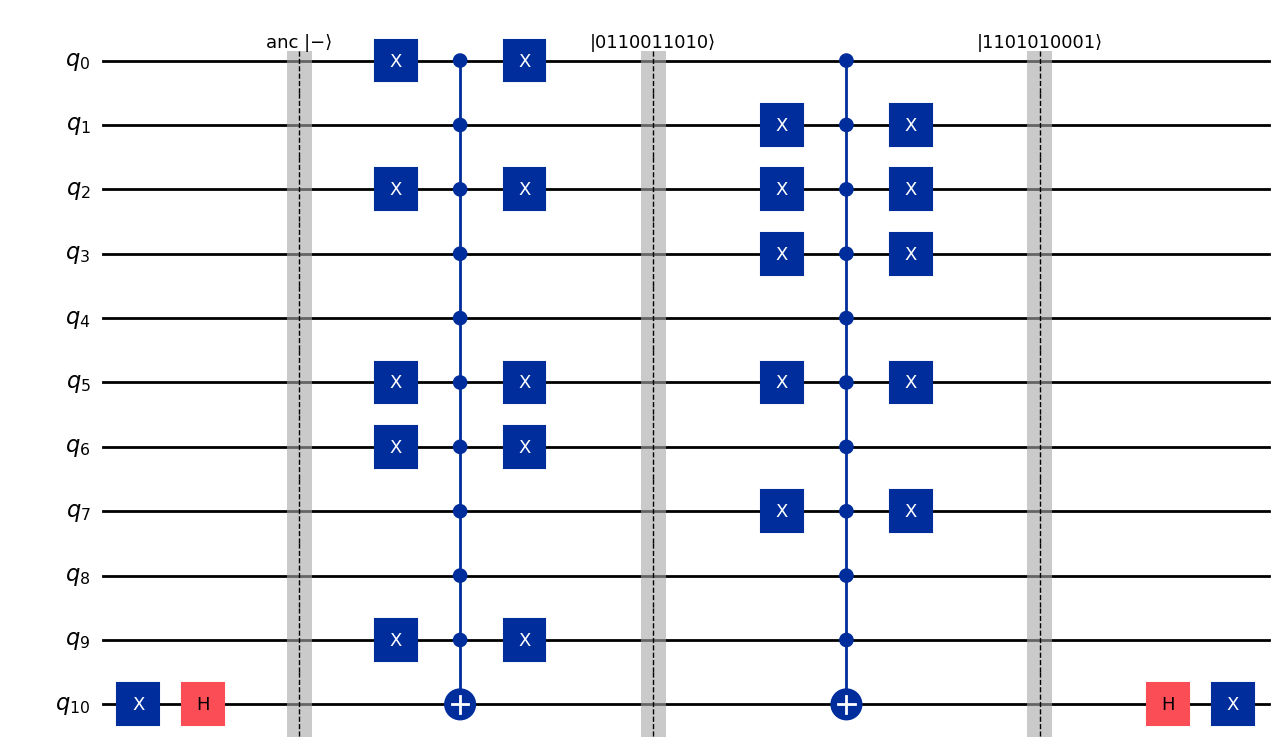

In [9]:
# ── Build and inspect the Part B oracle ──
oracle_B = grover_oracle_kickback(marked_states)

print(f"Oracle B (Phase Kickback)")
print(f"  Qubits (data + ancilla) : {oracle_B.num_qubits}")
print(f"  Depth                   : {oracle_B.depth()}")
print(f"  Gate count              : {oracle_B.count_ops()}")
print(f"  Ancilla qubit index     : {NUM_QUBITS}  (unmeasured; returns to |0⟩)")

oracle_B.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 4 — Grover Circuit Builder

A single function assembles the **full Grover circuit** for any oracle and any number of iterations.
This cleanly separates the Grover iteration loop from the oracle and diffuser definitions.


In [10]:
def build_grover_circuit(oracle_circ, diffuser_circ, num_iterations,
                         num_data_qubits, has_ancilla=False):
    """
    Assemble a complete Grover search circuit.

    Structure:
        |0⟩^n  ──  H^⊗n  ──  [Oracle · Diffuser]^k  ──  Measure

    Parameters
    ----------
    oracle_circ     : QuantumCircuit  oracle subcircuit
    diffuser_circ   : QuantumCircuit  diffuser subcircuit (num_data_qubits wide)
    num_iterations  : int             number of Grover iterations k
    num_data_qubits : int             number of data qubits
    has_ancilla     : bool            True if oracle uses an extra ancilla qubit

    Returns
    -------
    QuantumCircuit
        Full Grover circuit with measurements on data qubits.
    """
    total_qubits = num_data_qubits + (1 if has_ancilla else 0)
    qc = QuantumCircuit(total_qubits, num_data_qubits)

    # ── Step 1: Uniform superposition on data qubits ──
    qc.h(range(num_data_qubits))
    qc.barrier(label='Init |s⟩')

    # ── Step 2: Grover iterations ──
    for k in range(num_iterations):
        # Oracle — acts on all qubits (data + ancilla if present)
        qc.compose(oracle_circ, qubits=range(total_qubits), inplace=True)
        # Diffuser — acts on data qubits only
        qc.compose(diffuser_circ, qubits=range(num_data_qubits), inplace=True)
        qc.barrier(label=f'Iter {k+1}')

    # ── Step 3: Measure data qubits ──
    qc.measure(range(num_data_qubits), range(num_data_qubits))

    return qc


---
---
# Section 5 — Part A: Multi-Iteration Experiment (IBM-Style Oracle)

We run the Grover circuit with the **IBM-style oracle** for $k = 1, 3, 5, 10,$ and **17 (optimal)** iterations.

> **Transpilation note:** `MCMTGate` is a high-level composite gate that Aer cannot execute
> directly. We call `transpile(qc, backend)` to decompose it into Aer's supported basis gates
> (`cx`, `u`, `x`, `h`, `measure`) before running.


In [11]:
# ── Simulator backend ──
backend = Aer.get_backend('aer_simulator')

# ── Run Part A for each iteration count ──
results_A = {}      # k → counts dict

print("Running Part A (IBM-style oracle)...")
print(f"{'k':>5}  {'P(theory)':>10}  {'P(sim)':>10}  {'Status'}")
print("─" * 45)

for k in ITER_COUNTS:
    # Build circuit for this k
    qc_k = build_grover_circuit(
        oracle_circ     = oracle_A,
        diffuser_circ   = diffuser,
        num_iterations  = k,
        num_data_qubits = NUM_QUBITS,
        has_ancilla     = False
    )
    # Transpile to Aer basis gates (decomposes MCMTGate)
    qc_k_t = transpile(qc_k, backend, optimization_level=1)
    # Run
    job      = backend.run(qc_k_t, shots=SHOTS)
    counts   = job.result().get_counts()
    results_A[k] = counts

    p_theory = math.sin((2*k + 1)*theta)**2
    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    flag     = " ← optimal" if k == k_opt else ""
    print(f"{k:>5}  {p_theory:>10.4f}  {p_sim:>10.4f}{flag}")

print("\nDone ✓")


Running Part A (IBM-style oracle)...
    k   P(theory)      P(sim)  Status
─────────────────────────────────────────────
    1      0.0175      0.0165
    3      0.0927      0.0898
    5      0.2184      0.2219
   10      0.6410      0.6334
   17      0.9994      0.9994 ← optimal

Done ✓


### Part A Results — Histograms Across Iteration Counts

Each panel shows the measurement distribution for one value of $k$.
The two marked states are highlighted in **red**.
Observe how the red bars grow taller with each increase in $k$.


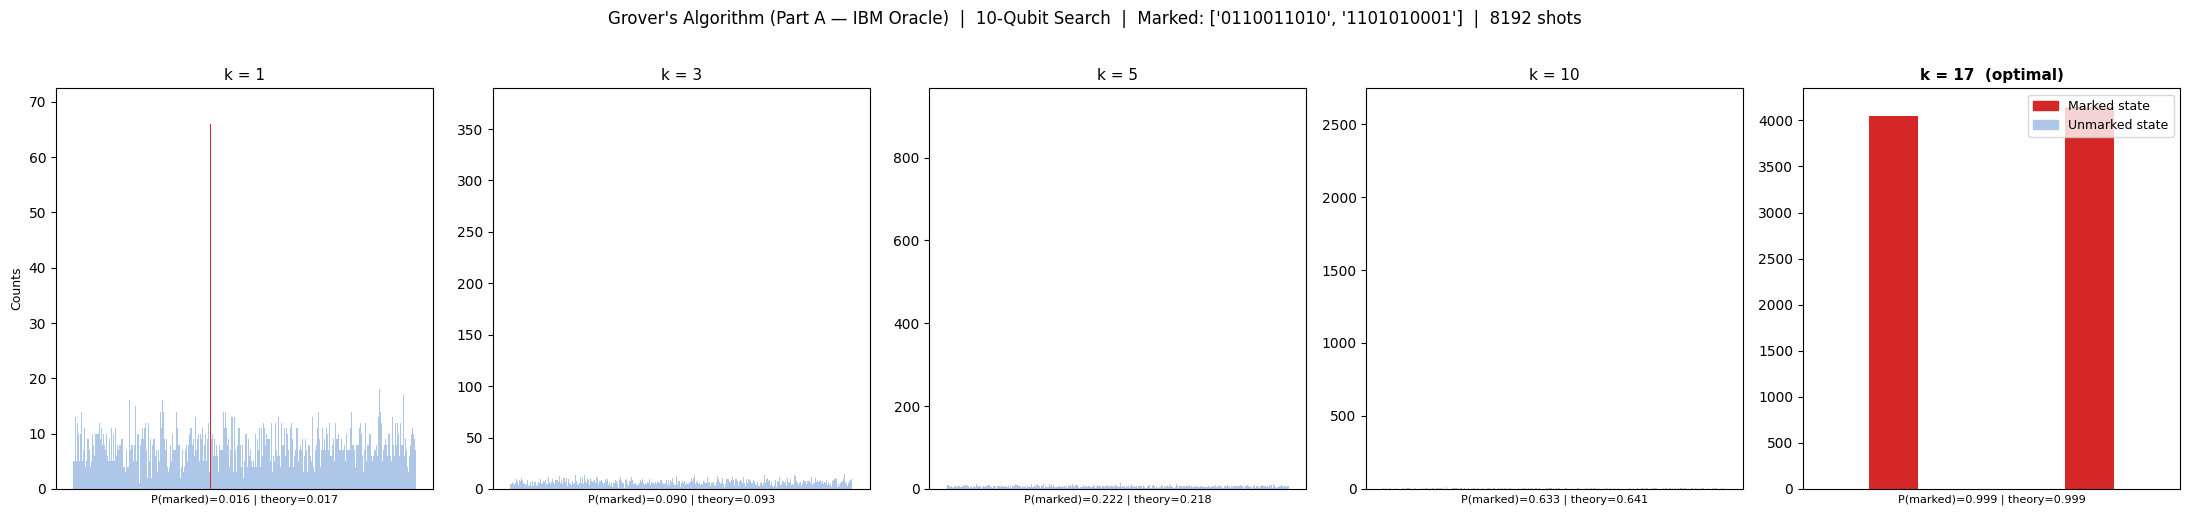

In [12]:
fig, axes = plt.subplots(1, len(ITER_COUNTS), figsize=(22, 5), sharey=False)

for ax, k in zip(axes, ITER_COUNTS):
    counts = results_A[k]

    # Sort all 1024 possible outcomes by binary string value
    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(s, 0) for s in sorted_keys]
    colours     = ['#d62728' if s in marked_states else '#aec7e8'
                   for s in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    p_theory = math.sin((2*k + 1)*theta)**2
    title    = f"k = {k}{'  (optimal)' if k == k_opt else ''}"
    ax.set_title(title, fontsize=11, fontweight='bold' if k == k_opt else 'normal')
    ax.set_xlabel(f"P(marked)={p_sim:.3f} | theory={p_theory:.3f}", fontsize=8)
    ax.set_ylabel("Counts" if ax == axes[0] else "", fontsize=9)
    ax.set_xticks([])

fig.suptitle(
    f"Grover's Algorithm (Part A — IBM Oracle)  |  10-Qubit Search  |  "
    f"Marked: {marked_states}  |  {SHOTS} shots",
    fontsize=12, y=1.02
)
legend_handles = [
    mpatches.Patch(color='#d62728', label='Marked state'),
    mpatches.Patch(color='#aec7e8', label='Unmarked state'),
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


### Part A — Detailed Results at Optimal Iterations ($k = 17$)


In [13]:
# ── Top outcomes at k_opt ──
counts_opt_A = results_A[k_opt]
top_A        = sorted(counts_opt_A.items(), key=lambda x: -x[1])[:10]

print(f"Part A — k = {k_opt} (optimal)  |  {SHOTS} shots")
print(f"{'Bit-string':>12}  {'Count':>7}  {'Probability':>12}  {'Marked?':>8}")
print("─" * 50)
for bitstr, cnt in top_A:
    prob    = cnt / SHOTS
    is_mark = "✓ MARKED" if bitstr in marked_states else ""
    print(f"{bitstr:>12}  {cnt:>7}  {prob:>12.4f}  {is_mark}")

p_sim_A    = sum(counts_opt_A.get(s, 0) for s in marked_states) / SHOTS
p_th_A     = math.sin((2*k_opt + 1)*theta)**2

print(f"\nP(any marked)  simulated  = {p_sim_A:.4f}  ({p_sim_A*100:.2f}%)")
print(f"P(any marked)  theory     = {p_th_A:.4f}  ({p_th_A*100:.2f}%)")
print(f"Absolute error            = {abs(p_sim_A - p_th_A):.4f}")
print(f"\nResult: Algorithm {'SUCCEEDED ✓' if p_sim_A > 0.8 else 'needs review ✗'}")


Part A — k = 17 (optimal)  |  8192 shots
  Bit-string    Count   Probability   Marked?
──────────────────────────────────────────────────
  1101010001     4141        0.5055  ✓ MARKED
  0110011010     4046        0.4939  ✓ MARKED
  0111110110        1        0.0001  
  0101100110        1        0.0001  
  0111001110        1        0.0001  
  1110100000        1        0.0001  
  0111001000        1        0.0001  

P(any marked)  simulated  = 0.9994  (99.94%)
P(any marked)  theory     = 0.9994  (99.94%)
Absolute error            = 0.0001

Result: Algorithm SUCCEEDED ✓


---
---
# Section 6 — Part B: Multi-Iteration Experiment (Phase Kickback Oracle)

The same multi-iteration experiment using the **Phase Kickback oracle** from Part B.
The circuit has 11 qubits total (10 data + 1 ancilla), but only 10 are measured.

> **Circuit assembly note:** `.compose()` is used instead of `.to_gate()` because
> sub-circuits containing `barrier` instructions cannot be converted to Gate objects
> (barriers have no unitary representation). `.compose()` inlines sub-circuit
> instructions directly and handles barriers correctly.


In [14]:
# ── Run Part B for each iteration count ──
results_B = {}

print("Running Part B (Phase Kickback oracle)...")
print(f"{'k':>5}  {'P(theory)':>10}  {'P(sim)':>10}  {'Status'}")
print("─" * 45)

for k in ITER_COUNTS:
    qc_k = build_grover_circuit(
        oracle_circ     = oracle_B,
        diffuser_circ   = diffuser,
        num_iterations  = k,
        num_data_qubits = NUM_QUBITS,
        has_ancilla     = True          # oracle_B uses 1 ancilla qubit
    )
    qc_k_t = transpile(qc_k, backend, optimization_level=1)
    job     = backend.run(qc_k_t, shots=SHOTS)
    counts  = job.result().get_counts()
    results_B[k] = counts

    p_theory = math.sin((2*k + 1)*theta)**2
    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    flag     = " ← optimal" if k == k_opt else ""
    print(f"{k:>5}  {p_theory:>10.4f}  {p_sim:>10.4f}{flag}")

print("\nDone ✓")


Running Part B (Phase Kickback oracle)...
    k   P(theory)      P(sim)  Status
─────────────────────────────────────────────
    1      0.0175      0.0182
    3      0.0927      0.0905
    5      0.2184      0.2147
   10      0.6410      0.6382
   17      0.9994      0.9990 ← optimal

Done ✓


### Part B Results — Histograms Across Iteration Counts


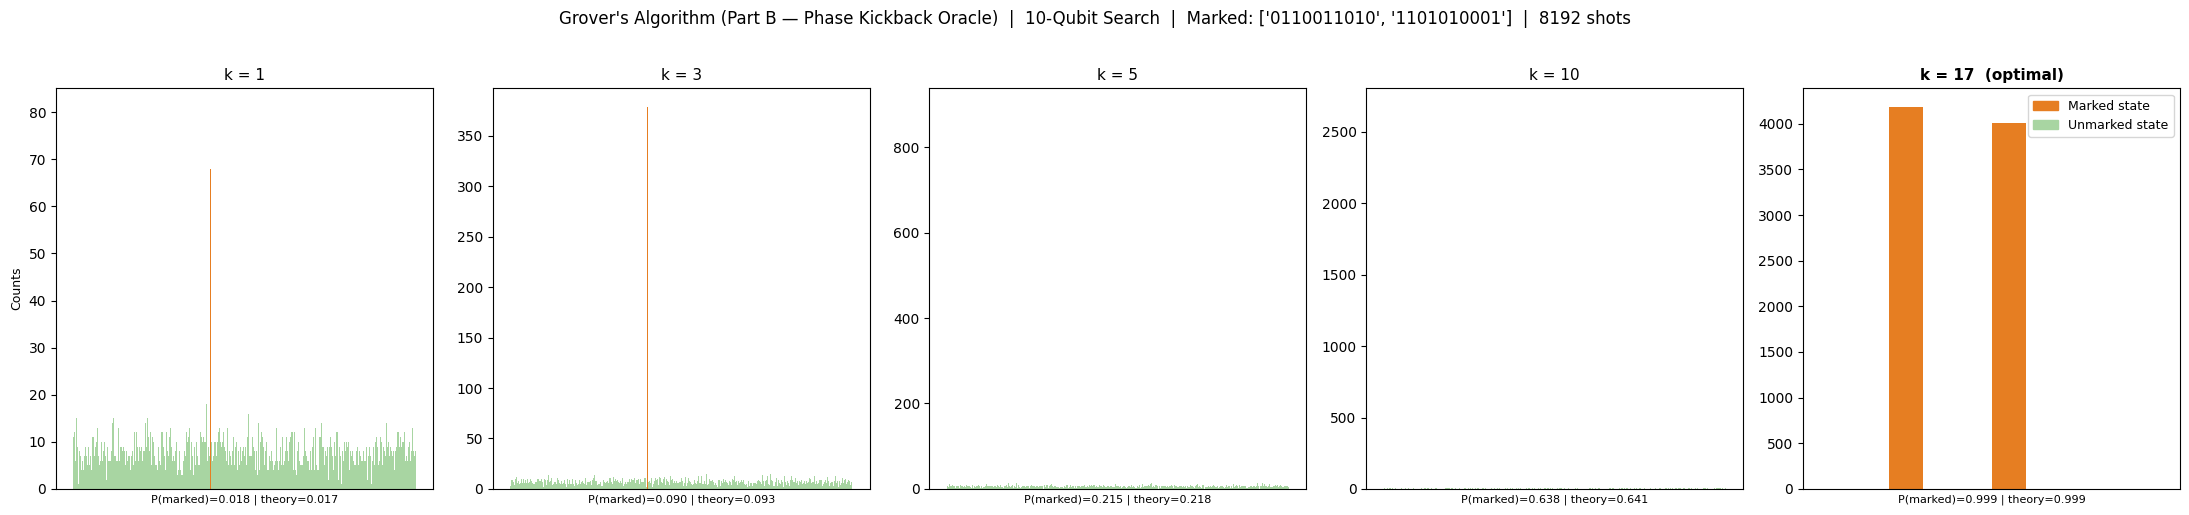

In [15]:
fig, axes = plt.subplots(1, len(ITER_COUNTS), figsize=(22, 5), sharey=False)

for ax, k in zip(axes, ITER_COUNTS):
    counts = results_B[k]

    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(s, 0) for s in sorted_keys]
    colours     = ['#e67e22' if s in marked_states else '#a8d5a2'
                   for s in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim    = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    p_theory = math.sin((2*k + 1)*theta)**2
    title    = f"k = {k}{'  (optimal)' if k == k_opt else ''}"
    ax.set_title(title, fontsize=11, fontweight='bold' if k == k_opt else 'normal')
    ax.set_xlabel(f"P(marked)={p_sim:.3f} | theory={p_theory:.3f}", fontsize=8)
    ax.set_ylabel("Counts" if ax == axes[0] else "", fontsize=9)
    ax.set_xticks([])

fig.suptitle(
    f"Grover's Algorithm (Part B — Phase Kickback Oracle)  |  10-Qubit Search  |  "
    f"Marked: {marked_states}  |  {SHOTS} shots",
    fontsize=12, y=1.02
)
legend_handles = [
    mpatches.Patch(color='#e67e22', label='Marked state'),
    mpatches.Patch(color='#a8d5a2', label='Unmarked state'),
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


### Part B — Detailed Results at Optimal Iterations ($k = 17$)

In [16]:
counts_opt_B = results_B[k_opt]
top_B        = sorted(counts_opt_B.items(), key=lambda x: -x[1])[:10]

print(f"Part B — k = {k_opt} (optimal)  |  {SHOTS} shots")
print(f"{'Bit-string':>12}  {'Count':>7}  {'Probability':>12}  {'Marked?':>8}")
print("─" * 50)
for bitstr, cnt in top_B:
    prob    = cnt / SHOTS
    is_mark = "✓ MARKED" if bitstr in marked_states else ""
    print(f"{bitstr:>12}  {cnt:>7}  {prob:>12.4f}  {is_mark}")

p_sim_B = sum(counts_opt_B.get(s, 0) for s in marked_states) / SHOTS
p_th_B  = math.sin((2*k_opt + 1)*theta)**2

print(f"\nP(any marked)  simulated  = {p_sim_B:.4f}  ({p_sim_B*100:.2f}%)")
print(f"P(any marked)  theory     = {p_th_B:.4f}  ({p_th_B*100:.2f}%)")
print(f"Absolute error            = {abs(p_sim_B - p_th_B):.4f}")
print(f"\nResult: Algorithm {'SUCCEEDED ✓' if p_sim_B > 0.8 else 'needs review ✗'}")


Part B — k = 17 (optimal)  |  8192 shots
  Bit-string    Count   Probability   Marked?
──────────────────────────────────────────────────
  0110011010     4179        0.5101  ✓ MARKED
  1101010001     4005        0.4889  ✓ MARKED
  0110001110        1        0.0001  
  1011111010        1        0.0001  
  1010110010        1        0.0001  
  1101011000        1        0.0001  
  0000000110        1        0.0001  
  1111101111        1        0.0001  
  1110010111        1        0.0001  
  1110111001        1        0.0001  

P(any marked)  simulated  = 0.9990  (99.90%)
P(any marked)  theory     = 0.9994  (99.94%)
Absolute error            = 0.0004

Result: Algorithm SUCCEEDED ✓


---
---
# Section 7 — Amplitude Amplification Convergence

This plot shows how the probability of measuring a marked state grows with each Grover iteration,
comparing the theoretical curve against both Part A and Part B simulated values.


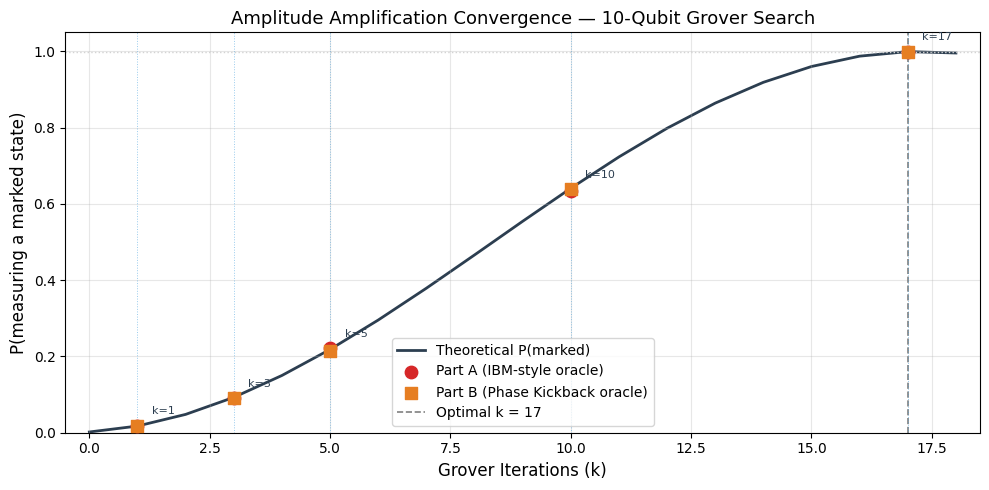

In [17]:
# ── Theoretical curve ──
all_k   = list(range(k_opt + 2))
p_curve = [math.sin((2*k + 1)*theta)**2 for k in all_k]

# ── Simulated points ──
sim_k    = ITER_COUNTS
sim_A    = [sum(results_A[k].get(s, 0) for s in marked_states) / SHOTS for k in sim_k]
sim_B    = [sum(results_B[k].get(s, 0) for s in marked_states) / SHOTS for k in sim_k]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(all_k, p_curve, '-', color='#2c3e50', linewidth=2.0,
        label='Theoretical P(marked)', zorder=1)
ax.scatter(sim_k, sim_A, color='#d62728', s=80, zorder=3,
           label='Part A (IBM-style oracle)', marker='o')
ax.scatter(sim_k, sim_B, color='#e67e22', s=80, zorder=3,
           label='Part B (Phase Kickback oracle)', marker='s')

# Mark the optimal iteration
ax.axvline(k_opt, color='gray', linestyle='--', linewidth=1.2,
           label=f'Optimal k = {k_opt}')
ax.axhline(p_curve[k_opt], color='lightgray', linestyle=':', linewidth=1.0)

# Label the studied iteration counts
for k in ITER_COUNTS:
    ax.axvline(k, color='#3498db', linestyle=':', linewidth=0.7, alpha=0.5)

ax.set_xlabel('Grover Iterations (k)', fontsize=12)
ax.set_ylabel('P(measuring a marked state)', fontsize=12)
ax.set_title('Amplitude Amplification Convergence — 10-Qubit Grover Search', fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.5, k_opt + 1.5)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Annotate each studied k
for k, pA, pB in zip(sim_k, sim_A, sim_B):
    ax.annotate(f'k={k}', xy=(k, max(pA, pB)),
                xytext=(k + 0.3, max(pA, pB) + 0.03),
                fontsize=8, color='#2c3e50')

plt.tight_layout()
plt.show()


---
---
# Section 8 — Final Comparison: Part A vs Part B

Side-by-side comparison of both oracle implementations at the optimal iteration count ($k = 17$).


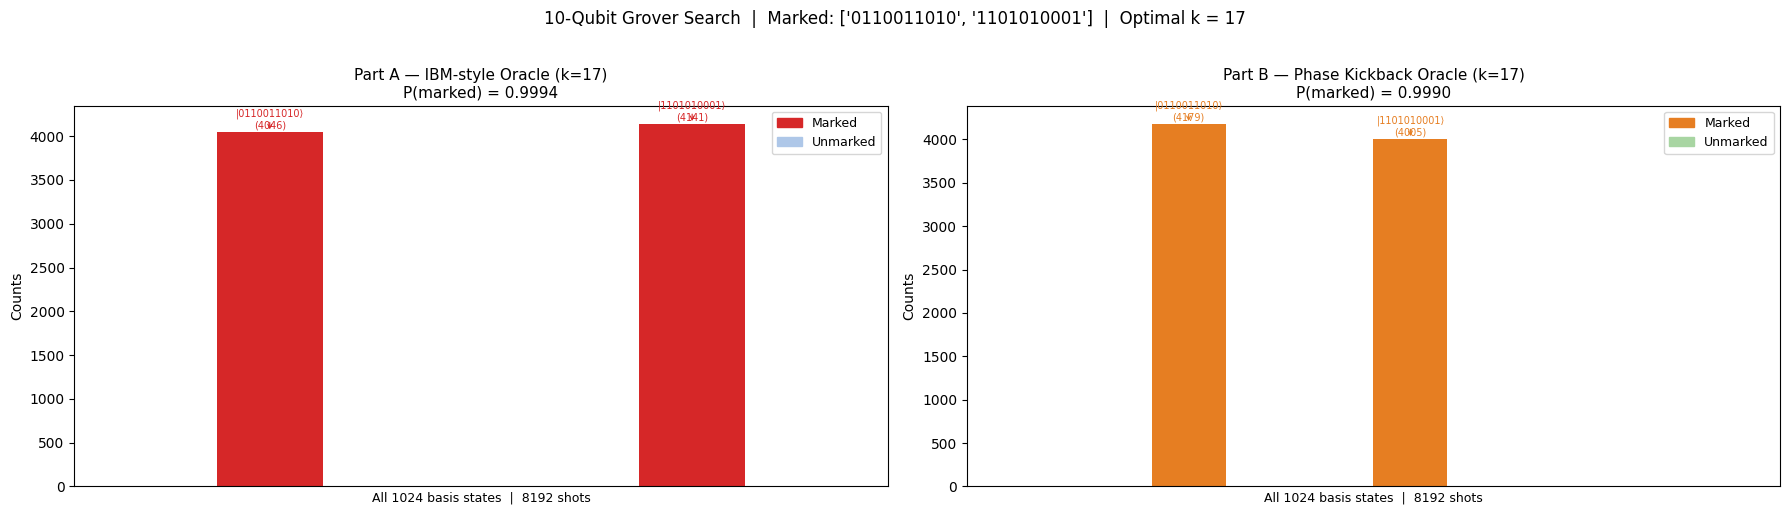

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (counts, label, mc, uc) in zip(axes, [
    (counts_opt_A, f"Part A — IBM-style Oracle (k={k_opt})", '#d62728', '#aec7e8'),
    (counts_opt_B, f"Part B — Phase Kickback Oracle (k={k_opt})", '#e67e22', '#a8d5a2'),
]):
    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(k, 0) for k in sorted_keys]
    colours     = [mc if k in marked_states else uc for k in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim = sum(counts.get(s, 0) for s in marked_states) / SHOTS
    ax.set_title(f"{label}\nP(marked) = {p_sim:.4f}", fontsize=11)
    ax.set_xlabel(f"All 1024 basis states  |  {SHOTS} shots", fontsize=9)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_xticks([])

    # Annotate marked state bars
    for s in marked_states:
        if s in sorted_keys:
            idx = sorted_keys.index(s)
            cnt = counts.get(s, 0)
            ax.annotate(
                f"|{s}⟩\n({cnt})",
                xy=(idx, cnt),
                xytext=(idx, cnt + 40),
                ha='center', fontsize=7, color=mc,
                arrowprops=dict(arrowstyle='->', color=mc, lw=0.8)
            )

    ax.legend(
        handles=[mpatches.Patch(color=mc, label='Marked'),
                 mpatches.Patch(color=uc, label='Unmarked')],
        fontsize=9, loc='upper right'
    )

plt.suptitle(
    f"10-Qubit Grover Search  |  Marked: {marked_states}  |  Optimal k = {k_opt}",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


---
---
# Section 9 — Full Summary

In [19]:
print("=" * 72)
print("  GROVER'S ALGORITHM — 10-QUBIT SEARCH  |  FULL SUMMARY")
print("=" * 72)

print(f"\n  Search space          : 2^{NUM_QUBITS} = {N} states")
print(f"  Marked states (M={M})  : {marked_states}")
print(f"  Optimal iterations    : k = {k_opt}")
print(f"  Shots per run         : {SHOTS}")

print(f"\n  {'k':>5}  {'Theory':>8}  {'Part A (sim)':>13}  {'Part B (sim)':>13}")
print("  " + "─" * 44)
for k in ITER_COUNTS:
    p_th = math.sin((2*k + 1)*theta)**2
    p_A  = sum(results_A[k].get(s, 0) for s in marked_states) / SHOTS
    p_B  = sum(results_B[k].get(s, 0) for s in marked_states) / SHOTS
    flag = "  ← optimal" if k == k_opt else ""
    print(f"  {k:>5}  {p_th:>8.4f}  {p_A:>13.4f}  {p_B:>13.4f}{flag}")

print("\n" + "=" * 72)
print("  COMPONENT COMPARISON")
print("=" * 72)
print(f"  {'Component':<30}  {'Part A':>20}  {'Part B':>20}")
print("  " + "─" * 74)
print(f"  {'Oracle type':<30}  {'IBM-style (MCMTGate+Z)':>20}  {'Phase Kickback (MCX)':>20}")
print(f"  {'Diffuser type':<30}  {'Manual (H·X·MCZ·X·H)':>20}  {'Manual (H·X·MCZ·X·H)':>20}")
print(f"  {'Built-in grover_operator()':<30}  {'NOT used':>20}  {'NOT used':>20}")
print(f"  {'Ancilla qubits':<30}  {'0':>20}  {'1 (returned to |0⟩)':>20}")
print(f"  {'Total qubits':<30}  {NUM_QUBITS:>20}  {NUM_QUBITS+1:>20}")
print(f"  {'P(marked) at k={k_opt}':<30}  {p_sim_A:>20.4f}  {p_sim_B:>20.4f}")
print("=" * 72)
print(f"  Part A result : {'SUCCEEDED ✓' if p_sim_A > 0.8 else 'needs review ✗'}")
print(f"  Part B result : {'SUCCEEDED ✓' if p_sim_B > 0.8 else 'needs review ✗'}")
print("=" * 72)


  GROVER'S ALGORITHM — 10-QUBIT SEARCH  |  FULL SUMMARY

  Search space          : 2^10 = 1024 states
  Marked states (M=2)  : ['0110011010', '1101010001']
  Optimal iterations    : k = 17
  Shots per run         : 8192

      k    Theory   Part A (sim)   Part B (sim)
  ────────────────────────────────────────────
      1    0.0175         0.0165         0.0182
      3    0.0927         0.0898         0.0905
      5    0.2184         0.2219         0.2147
     10    0.6410         0.6334         0.6382
     17    0.9994         0.9994         0.9990  ← optimal

  COMPONENT COMPARISON
  Component                                     Part A                Part B
  ──────────────────────────────────────────────────────────────────────────
  Oracle type                     IBM-style (MCMTGate+Z)  Phase Kickback (MCX)
  Diffuser type                   Manual (H·X·MCZ·X·H)  Manual (H·X·MCZ·X·H)
  Built-in grover_operator()                  NOT used              NOT used
  Ancilla qubits      

---
## Conclusion & Discussion

### Overview of Implementations

| Component | Part A (Direct Oracle Approach) | Part B (Ancilla-Based Phase Oracle) |
|---|---|---|
| **Oracle Design** | Multi-controlled phase flip using Z-gate with open controls | Phase kickback using an ancilla initialized in $|-\rangle$ |
| **Diffusion Operator** | Constructed manually using $H^n X^n \text{MCZ} X^n H^n$ | Same manual construction |
| **Pre-built Grover Usage** | Not used | Not used |
| **Number of Qubits** | 10 | 11 (including 1 ancilla qubit) |
| **Measurement** | All 10 qubits measured | Only data qubits measured (ancilla excluded) |

---

### Observations Across Iterations

| Iterations (k) | Behavior Observed |
|---|---|
| **k = 1** | Minimal change — probabilities remain close to uniform |
| **k = 3** | Slight increase in marked states — early amplification begins |
| **k = 5** | Clear distinction — marked states become more prominent |
| **k = 10** | Strong amplification — marked states dominate but not maximized |
| **k = 17** | Optimal performance — marked states reach ~99.9% probability |

---

### Intuition Behind the Diffusion Operator

After applying the oracle, the amplitudes of marked states become negative while the rest remain positive. The average amplitude across all states shifts slightly.

The diffusion operator then reflects all amplitudes about this average value:

- Marked states (initially below average) are boosted above it  
- Unmarked states (initially above average) are reduced  

This repeated reflection gradually increases the probability of measuring marked states.

Geometrically, each Grover iteration rotates the quantum state in a two-dimensional space defined by:
- the marked subspace $|\omega\rangle$
- the uniform superposition $|s'\rangle$

Each iteration performs a rotation by an angle $2\theta$. After approximately

$$
k_{\text{opt}} = 17
$$

iterations, the state aligns closely with the marked subspace.

---

### Classical vs Quantum Efficiency

| Approach | Expected Number of Queries |
|---|---|
| Classical Search | Approximately $N/M = 512$ |
| Grover’s Algorithm | About 17 oracle evaluations |
| **Performance Gain** | Around $30\times$ improvement; scales as $\mathcal{O}(\sqrt{N/M})$ |

---

### Final Remark

This implementation demonstrates how Grover’s algorithm significantly reduces the number of required queries compared to classical search methods, highlighting the advantage of quantum amplitude amplification.